In [1]:
print("02_Preprocessing notebook is working!")

02_Preprocessing notebook is working!


In [2]:
import sys
print(sys.executable)

/Users/gavidurushela/DL ass/plant-disease-classification/venv/bin/python3.12


# 02 - Preprocessing & Data Pipeline

## Objective

This notebook implements the preprocessing and data pipeline for
plant disease classification using three classes:

- Healthy
- Powdery
- Rust

The preprocessing pipeline includes:

- Dataset loading
- Class mapping
- Image resizing
- MobileNetV2-specific preprocessing
- Training-only data augmentation
- Train, validation, and test pipeline creation
- Pipeline verification
- Preprocessing visualization

The test dataset is kept separate from model development and
hyperparameter tuning and is reserved for final evaluation.

In [7]:
import os
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from pathlib import Path

In [8]:
print("TensorFlow version:", tf.__version__)
print("Python executable:", __import__("sys").executable)

TensorFlow version: 2.21.0
Python executable: /Users/gavidurushela/DL ass/plant-disease-classification/venv/bin/python3.12


In [9]:
# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Dataset paths
DATASET_DIR = Path("../dataset")

TRAIN_DIR = DATASET_DIR / "Train"
VALIDATION_DIR = DATASET_DIR / "Validation"
TEST_DIR = DATASET_DIR / "Test"

# Image configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Classes
CLASS_NAMES = ["Healthy", "Powdery", "Rust"]
NUM_CLASSES = len(CLASS_NAMES)

print("Dataset directory:", DATASET_DIR)
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Classes:", CLASS_NAMES)

Dataset directory: ../dataset
Image size: (224, 224)
Batch size: 32
Classes: ['Healthy', 'Powdery', 'Rust']


In [7]:
print("Train directory exists:", TRAIN_DIR.exists())
print("Validation directory exists:", VALIDATION_DIR.exists())
print("Test directory exists:", TEST_DIR.exists())

Train directory exists: True
Validation directory exists: True
Test directory exists: True


In [8]:
for class_name in CLASS_NAMES:
    train_count = len(list((TRAIN_DIR / class_name).glob("*.jpg")))
    validation_count = len(list((VALIDATION_DIR / class_name).glob("*.jpg")))
    test_count = len(list((TEST_DIR / class_name).glob("*.jpg")))

    print(
        f"{class_name:10s} | "
        f"Train: {train_count:3d} | "
        f"Validation: {validation_count:2d} | "
        f"Test: {test_count:2d}"
    )

Healthy    | Train: 458 | Validation: 20 | Test: 50
Powdery    | Train: 430 | Validation: 20 | Test: 50
Rust       | Train: 434 | Validation: 20 | Test: 50


## 6. Load Image Datasets

The dataset is loaded using the predefined Train, Validation, and Test
directories.

Training data is shuffled to support model training, while validation
and test data are not shuffled to keep evaluation deterministic.

Images are resized to 224 × 224 pixels during loading to provide a
consistent input size for the MobileNetV2 model.

In [33]:
# Load training dataset

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

# Load validation dataset

validation_ds = tf.keras.utils.image_dataset_from_directory(
    VALIDATION_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Load test dataset

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 1322 files belonging to 3 classes.
Found 60 files belonging to 3 classes.
Found 150 files belonging to 3 classes.


In [10]:
print("Class names:", train_ds.class_names)

Class names: ['Healthy', 'Powdery', 'Rust']


## 7. Verify Dataset Batches

Before applying model-specific preprocessing, the loaded batches are
checked to confirm the image tensor shape, label shape, data type,
pixel-value range, and class labels.

In [11]:
# Get one batch from the training dataset

images, labels = next(iter(train_ds))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image data type:", images.dtype)
print("Label data type:", labels.dtype)

print("Minimum pixel value:", tf.reduce_min(images).numpy())
print("Maximum pixel value:", tf.reduce_max(images).numpy())

print("Labels in first batch:", labels.numpy())

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Image data type: <dtype: 'float32'>
Label data type: <dtype: 'int32'>
Minimum pixel value: 0.0
Maximum pixel value: 255.0
Labels in first batch: [1 1 2 0 0 1 0 1 2 1 1 2 1 1 1 1 1 2 2 0 0 0 0 1 1 0 1 0 0 0 2 0]


## 8. Visualize Resized Training Images

A sample of resized training images is visualized together with their
class labels to verify that the images and labels have been loaded
correctly.

At this stage, the images have been resized to 224 × 224 pixels but
have not yet undergone MobileNetV2-specific preprocessing or data
augmentation.

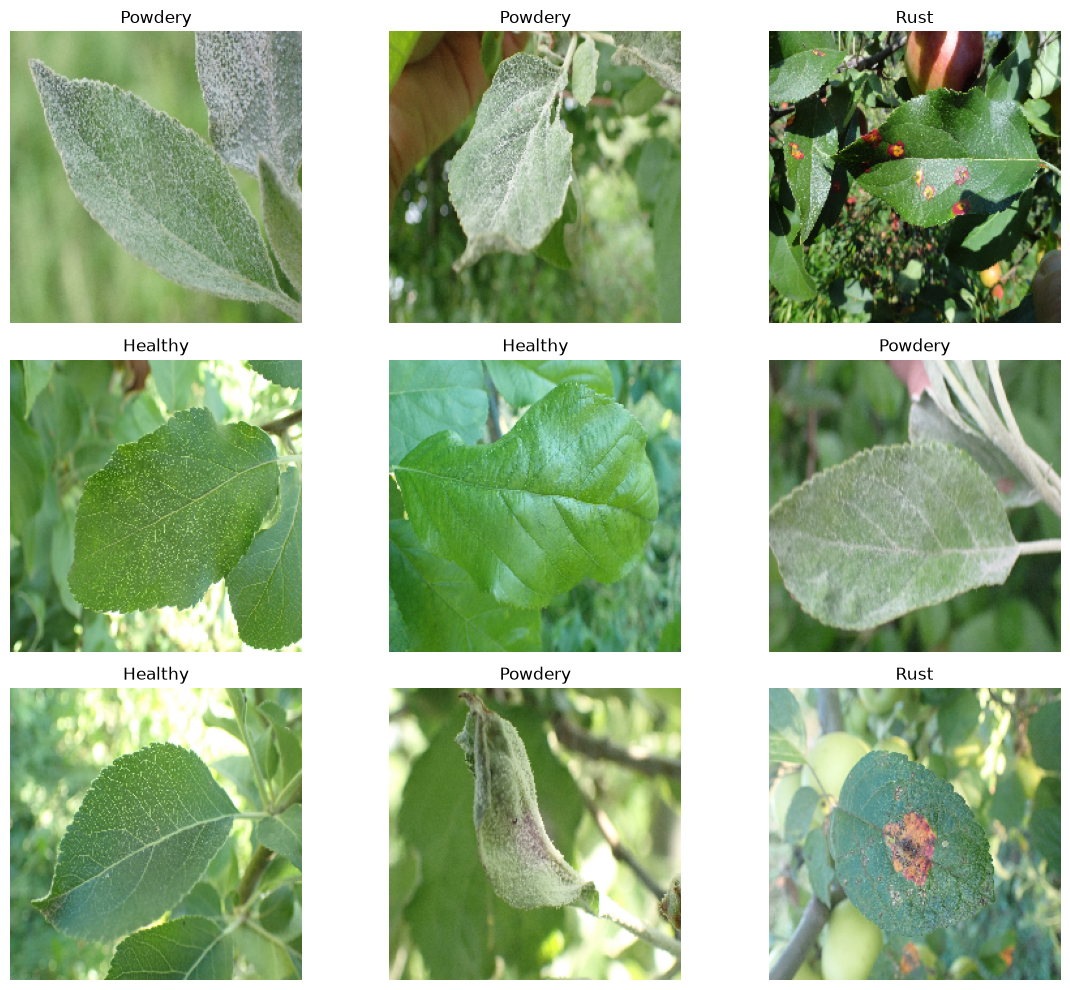

In [12]:
# Display sample training images

plt.figure(figsize=(12, 10))

for i in range(9):
    ax = plt.subplot(3, 3, i + 1)

    plt.imshow(images[i].numpy().astype("uint8"))

    class_index = labels[i].numpy()
    plt.title(CLASS_NAMES[class_index])
    plt.axis("off")

plt.tight_layout()
plt.show()

## 9. MobileNetV2-Specific Preprocessing

MobileNetV2 uses model-specific input preprocessing. The input images
are converted to floating-point tensors and passed through the
MobileNetV2 `preprocess_input` function.

This preprocessing transforms pixel values from the original
0–255 range to the range expected by MobileNetV2.

In [16]:
def mobilenet_preprocess(images, labels):
    images = tf.cast(images, tf.float32)
    images = tf.keras.applications.mobilenet_v2.preprocess_input(images)
    return images, labels

In [17]:
processed_images, processed_labels = mobilenet_preprocess(
    images, labels
)

print("Original pixel range:")
print("Min:", tf.reduce_min(images).numpy())
print("Max:", tf.reduce_max(images).numpy())

print("\nAfter MobileNetV2 preprocessing:")
print("Min:", tf.reduce_min(processed_images).numpy())
print("Max:", tf.reduce_max(processed_images).numpy())

print("\nProcessed image shape:", processed_images.shape)
print("Labels shape:", processed_labels.shape)

Original pixel range:
Min: 0.0
Max: 255.0

After MobileNetV2 preprocessing:
Min: -1.0
Max: 1.0

Processed image shape: (32, 224, 224, 3)
Labels shape: (32,)


## 10. Data Augmentation

Data augmentation is applied only to the training images to improve
model generalization and reduce sensitivity to variations in leaf
orientation and image composition.

The initial augmentation configuration uses conservative geometric
transformations:

- Horizontal flipping
- Small rotations
- Small translations
- Moderate zoom

Validation and test images are not augmented because they must
represent the original evaluation data distribution.

In [28]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip(
            mode="horizontal",
            seed=SEED
        ),
        tf.keras.layers.RandomRotation(
            factor=0.05,
            seed=SEED
        ),
        tf.keras.layers.RandomTranslation(
            height_factor=0.05,
            width_factor=0.05,
            seed=SEED
        ),
        tf.keras.layers.RandomZoom(
            height_factor=0.10,
            width_factor=0.10,
            seed=SEED
        ),
    ],
    name="data_augmentation"
)

## 11. Visualize Data Augmentation

The effect of the augmentation pipeline is visualized by applying
the transformations to sample training images.

The purpose is to verify that the augmented images remain realistic
plant-leaf images and that disease-related visual features are not
removed or excessively distorted.

In [34]:
images, labels = next(iter(train_ds))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: (32, 224, 224, 3)
Labels shape: (32,)


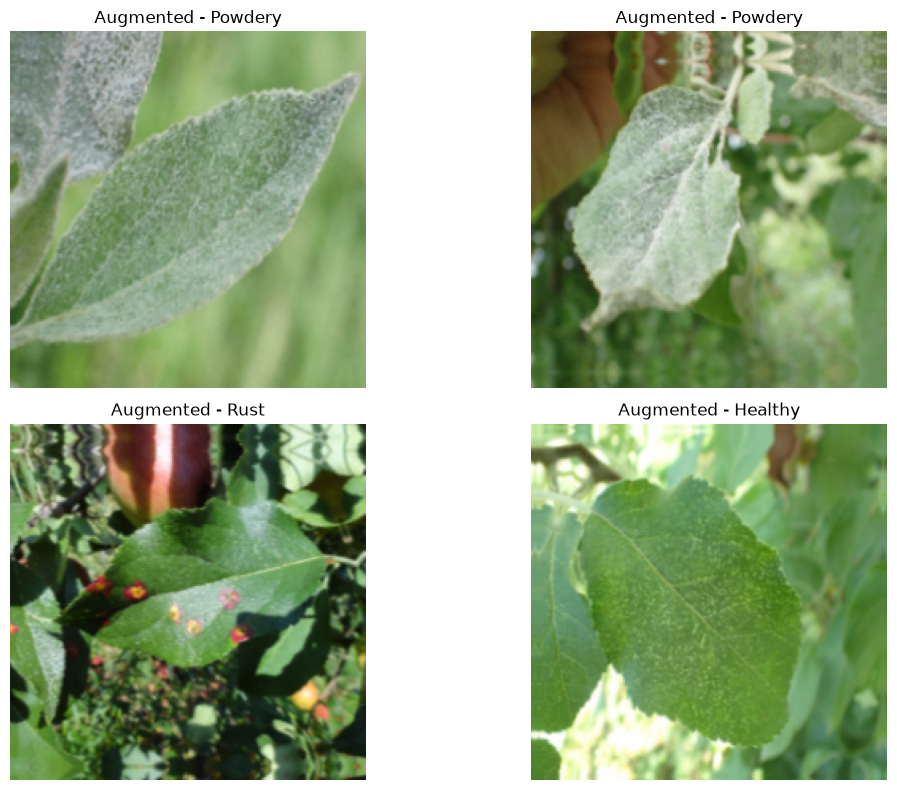

In [35]:
# Select a few original images

sample_images = images[:4]

plt.figure(figsize=(12, 8))

for i in range(4):
    ax = plt.subplot(2, 2, i + 1)

    augmented_image = data_augmentation(
        tf.expand_dims(sample_images[i], axis=0),
        training=True
    )[0]

    augmented_image = tf.clip_by_value(
        augmented_image,
        0.0,
        255.0
    )

    plt.imshow(
        augmented_image.numpy().astype("uint8")
    )

    class_index = labels[i].numpy()
    plt.title(f"Augmented - {CLASS_NAMES[class_index]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 12. Build Preprocessing Pipelines

The final preprocessing pipeline applies data augmentation only to the
training dataset.

Training images are augmented before MobileNetV2-specific preprocessing.

Validation and test images are not augmented. They only undergo the
MobileNetV2 preprocessing required by the model.

This ensures that validation and test evaluation is performed on
unmodified images apart from the required model preprocessing.

In [41]:
def preprocess_train(images, labels):
    # Apply augmentation first
    images = data_augmentation(images, training=True)

    # Apply MobileNetV2 preprocessing
    images = tf.cast(images, tf.float32)
    images = tf.keras.applications.mobilenet_v2.preprocess_input(images)

    return images, labels

In [42]:
def preprocess_eval(images, labels):
    # No augmentation for validation or test
    images = tf.cast(images, tf.float32)

    # MobileNetV2 preprocessing
    images = tf.keras.applications.mobilenet_v2.preprocess_input(images)

    return images, labels

In [43]:
train_pipeline = train_ds.map(
    preprocess_train,
    num_parallel_calls=tf.data.AUTOTUNE
)

validation_pipeline = validation_ds.map(
    preprocess_eval,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_pipeline = test_ds.map(
    preprocess_eval,
    num_parallel_calls=tf.data.AUTOTUNE
)


In [44]:
train_pipeline = train_pipeline.prefetch(tf.data.AUTOTUNE)
validation_pipeline = validation_pipeline.prefetch(tf.data.AUTOTUNE)
test_pipeline = test_pipeline.prefetch(tf.data.AUTOTUNE)

## 13. Verify Final Preprocessing Pipelines

The final train, validation, and test pipelines are checked to verify
that image dimensions remain consistent and that MobileNetV2
preprocessing produces the expected input value range.

In [45]:
train_images, train_labels = next(iter(train_pipeline))
val_images, val_labels = next(iter(validation_pipeline))
test_images, test_labels = next(iter(test_pipeline))

print("TRAIN")
print("Images:", train_images.shape)
print("Labels:", train_labels.shape)
print("Pixel range:",
      tf.reduce_min(train_images).numpy(),
      "to",
      tf.reduce_max(train_images).numpy())

print("\nVALIDATION")
print("Images:", val_images.shape)
print("Labels:", val_labels.shape)
print("Pixel range:",
      tf.reduce_min(val_images).numpy(),
      "to",
      tf.reduce_max(val_images).numpy())

print("\nTEST")
print("Images:", test_images.shape)
print("Labels:", test_labels.shape)
print("Pixel range:",
      tf.reduce_min(test_images).numpy(),
      "to",
      tf.reduce_max(test_images).numpy())

TRAIN
Images: (32, 224, 224, 3)
Labels: (32,)
Pixel range: -0.99901843 to 1.0

VALIDATION
Images: (32, 224, 224, 3)
Labels: (32,)
Pixel range: -1.0 to 1.0

TEST
Images: (32, 224, 224, 3)
Labels: (32,)
Pixel range: -1.0 to 1.0


## 14. MobileNetV2 Baseline Model

MobileNetV2 is evaluated using transfer learning with ImageNet-pretrained
weights.

The initial baseline keeps the MobileNetV2 convolutional backbone frozen
and trains only a new classification head for the three plant disease
classes.

This provides a baseline before any fine-tuning is performed.

In [46]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

print("Base model loaded successfully.")
print("Backbone trainable:", base_model.trainable)

Base model loaded successfully.
Backbone trainable: False


## 14.2 Build the Classification Head

The ImageNet-pretrained MobileNetV2 backbone is used as a frozen
feature extractor. A new classification head is added for the
three plant disease classes.

The classification head consists of:

- Global Average Pooling
- Dropout
- Dense layer with 3 output classes
- Softmax activation

In [47]:
inputs = tf.keras.Input(
    shape=IMG_SIZE + (3,),
    name="input"
)

# Frozen MobileNetV2 feature extractor
x = base_model(
    inputs,
    training=False
)

# Classification head
x = tf.keras.layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

x = tf.keras.layers.Dropout(
    0.2,
    name="dropout"
)(x)

outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="classifier"
)(x)

mobilenet_model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="MobileNetV2_Plant_Disease"
)

mobilenet_model.summary()
print("MobileNetV2 model created successfully.")
print("Backbone trainable:", base_model.trainable)

Model: "MobileNetV2_Plant_Disease"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

MobileNetV2 model created successfully.
Backbone trainable: False


In [12]:
print("Total parameters:", mobilenet_model.count_params())

trainable_params = sum(
    np.prod(v.shape)
    for v in mobilenet_model.trainable_variables
)

non_trainable_params = sum(
    np.prod(v.shape)
    for v in mobilenet_model.non_trainable_variables
)

print("Trainable parameters:", trainable_params)
print("Non-trainable parameters:", non_trainable_params)

Total parameters: 2261827
Trainable parameters: 3843
Non-trainable parameters: 2257986


## 15. Compile MobileNetV2 Baseline

The initial MobileNetV2 model is compiled using the Adam optimizer
with a baseline learning rate of 0.001.

Sparse categorical cross-entropy is used because the dataset labels
are integer encoded and there are three mutually exclusive classes.

In [56]:
# 18. Rebuild Fresh MobileNetV2 Baseline

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = tf.keras.Input(
    shape=IMG_SIZE + (3,),
    name="input"
)

x = base_model(inputs, training=False)

x = tf.keras.layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

x = tf.keras.layers.Dropout(
    0.2,
    name="dropout"
)(x)

outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="classifier"
)(x)

mobilenet_model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="MobileNetV2_Plant_Disease"
)

print("Fresh MobileNetV2 model created.")
print("Backbone trainable:", base_model.trainable)

Fresh MobileNetV2 model created.
Backbone trainable: False


In [57]:
# 19. Compile Fresh Baseline

BASELINE_LR = 1e-3

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=BASELINE_LR
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled.")
print("Configured learning rate:", BASELINE_LR)
print(
    "Actual optimizer learning rate:",
    mobilenet_model.optimizer.learning_rate.numpy()
)

Model compiled.
Configured learning rate: 0.001
Actual optimizer learning rate: 0.001


In [58]:
# 20. Fresh Training Callbacks

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

print("Fresh callbacks configured.")

Fresh callbacks configured.


## 16. Train MobileNetV2 Frozen Baseline

The first experiment trains the classification head while keeping
the ImageNet-pretrained MobileNetV2 backbone frozen.

The validation set is used to monitor training performance. The test
set is not used during training.

In [59]:
# 21. MNV2-BASE-01 — Final Baseline Training

import time

start_time = time.time()

history = mobilenet_model.fit(
    train_pipeline,
    validation_data=validation_pipeline,
    epochs=20,
    callbacks=[
        early_stopping,
        reduce_lr
    ],
    verbose=1
)

training_time = time.time() - start_time

print("\nMNV2-BASE-01 training completed.")
print(f"Total training time: {training_time:.2f} seconds")
print(f"Total training time: {training_time / 60:.2f} minutes")

Epoch 1/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 15s 326ms/step - accuracy: 0.7617 - loss: 0.5814 - val_accuracy: 0.9500 - val_loss: 0.2523 - learning_rate: 0.0010
Epoch 2/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 14s 333ms/step - accuracy: 0.9342 - loss: 0.2352 - val_accuracy: 0.9500 - val_loss: 0.1717 - learning_rate: 0.0010
Epoch 3/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 15s 346ms/step - accuracy: 0.9365 - loss: 0.1765 - val_accuracy: 0.9500 - val_loss: 0.1395 - learning_rate: 0.0010
Epoch 4/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 15s 345ms/step - accuracy: 0.9644 - loss: 0.1366 - val_accuracy: 0.9667 - val_loss: 0.1595 - learning_rate: 0.0010
Epoch 5/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 15s 353ms/step - accuracy: 0.9614 - loss: 0.1286 - val_accuracy: 0.9833 - val_loss: 0.0995 - learning_rate: 0.0010
Epoch 6/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 16s 376ms/step - accuracy: 0.9690 - loss: 0.1096 - val_accuracy: 0.9667 - val_loss: 0.1126 - learning_rate: 0.0010
Epoch 7/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.9705 - loss: 0.1

In [60]:
# 22. Record MNV2-BASE-01 Results

baseline_result = {
    "experiment_id": "MNV2-BASE-01",
    "model": "MobileNetV2",
    "weights": "ImageNet",
    "input_size": "224x224",
    "batch_size": 32,
    "dropout": 0.2,
    "backbone_frozen": True,
    "initial_learning_rate": 0.001,
    "epochs_max": 20,
    "epochs_run": len(history.history["loss"]),
    "best_epoch": int(np.argmin(history.history["val_loss"])) + 1,
    "best_val_loss": float(min(history.history["val_loss"])),
    "best_val_accuracy": float(max(history.history["val_accuracy"])),
    "training_time_seconds": training_time,
}

for key, value in baseline_result.items():
    print(f"{key}: {value}")

experiment_id: MNV2-BASE-01
model: MobileNetV2
weights: ImageNet
input_size: 224x224
batch_size: 32
dropout: 0.2
backbone_frozen: True
initial_learning_rate: 0.001
epochs_max: 20
epochs_run: 14
best_epoch: 9
best_val_loss: 0.07840599864721298
best_val_accuracy: 0.9833333492279053
training_time_seconds: 286.38924193382263


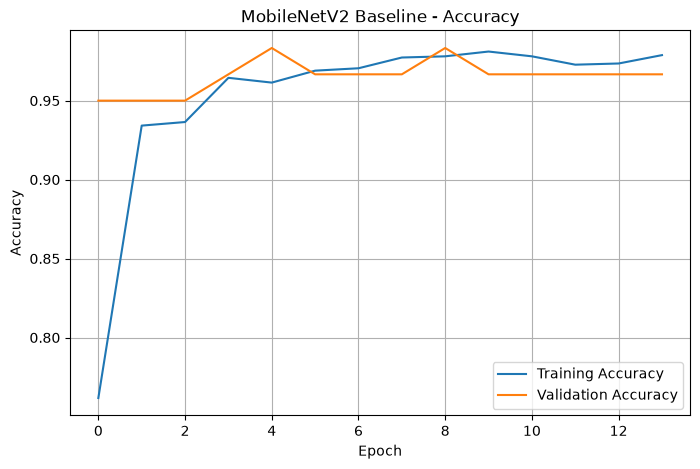

In [61]:
# 22. Plot Training History

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("MobileNetV2 Baseline - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

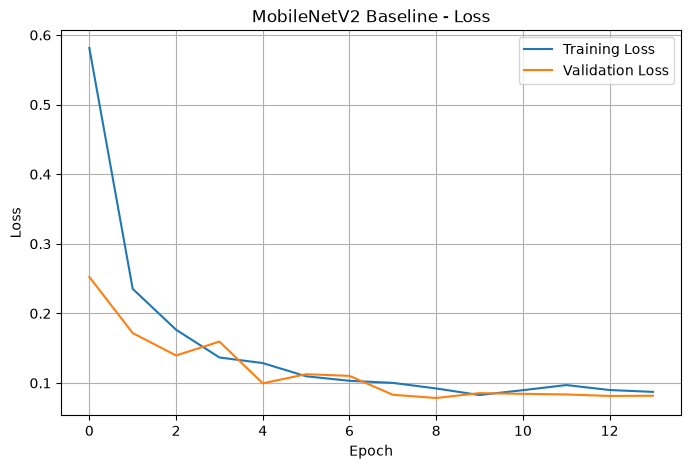

In [62]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("MobileNetV2 Baseline - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [63]:
# 23. Check MobileNetV2 Layers

print("Total MobileNetV2 layers:", len(base_model.layers))

for i, layer in enumerate(base_model.layers[-20:]):
    print(
        len(base_model.layers) - 20 + i,
        layer.name,
        type(layer).__name__
    )

Total MobileNetV2 layers: 154
134 block_15_expand Conv2D
135 block_15_expand_BN BatchNormalization
136 block_15_expand_relu ReLU
137 block_15_depthwise DepthwiseConv2D
138 block_15_depthwise_BN BatchNormalization
139 block_15_depthwise_relu ReLU
140 block_15_project Conv2D
141 block_15_project_BN BatchNormalization
142 block_15_add Add
143 block_16_expand Conv2D
144 block_16_expand_BN BatchNormalization
145 block_16_expand_relu ReLU
146 block_16_depthwise DepthwiseConv2D
147 block_16_depthwise_BN BatchNormalization
148 block_16_depthwise_relu ReLU
149 block_16_project Conv2D
150 block_16_project_BN BatchNormalization
151 Conv_1 Conv2D
152 Conv_1_bn BatchNormalization
153 out_relu ReLU


In [64]:
# 24. Configure MobileNetV2 Fine-Tuning

# Start by keeping the entire backbone frozen
base_model.trainable = True

# Freeze earlier layers and BatchNormalization layers
fine_tune_from = 134

for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

for layer in base_model.layers[fine_tune_from:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

# Display trainable layers
print("Fine-tuning starts from layer:", fine_tune_from)
print("Total backbone layers:", len(base_model.layers))

trainable_backbone_layers = sum(
    1 for layer in base_model.layers if layer.trainable
)

print("Trainable backbone layers:", trainable_backbone_layers)

Fine-tuning starts from layer: 134
Total backbone layers: 154
Trainable backbone layers: 13


In [65]:
# 25. Compile Fine-Tuned MobileNetV2

FINE_TUNE_LR = 1e-5

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=FINE_TUNE_LR
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Fine-tuned model compiled.")
print("Fine-tuning learning rate:", FINE_TUNE_LR)
print(
    "Actual optimizer learning rate:",
    mobilenet_model.optimizer.learning_rate.numpy()
)

Fine-tuned model compiled.
Fine-tuning learning rate: 1e-05
Actual optimizer learning rate: 1e-05


In [66]:
# 26. Fine-Tuning Callbacks

fine_tune_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

fine_tune_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

print("Fine-tuning callbacks configured successfully.")

Fine-tuning callbacks configured successfully.


In [67]:
# 27. Train MNV2-FT-01

import time

fine_tune_start = time.time()

fine_tune_history = mobilenet_model.fit(
    train_pipeline,
    validation_data=validation_pipeline,
    epochs=15,
    callbacks=[
        fine_tune_early_stopping,
        fine_tune_reduce_lr
    ],
    verbose=1
)

fine_tune_time = time.time() - fine_tune_start

print("\nMNV2-FT-01 training completed.")
print(f"Total fine-tuning time: {fine_tune_time:.2f} seconds")
print(f"Total fine-tuning time: {fine_tune_time / 60:.2f} minutes")

Epoch 1/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 16s 346ms/step - accuracy: 0.9766 - loss: 0.0793 - val_accuracy: 1.0000 - val_loss: 0.0472 - learning_rate: 1.0000e-05
Epoch 2/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 15s 344ms/step - accuracy: 0.9803 - loss: 0.0608 - val_accuracy: 0.9667 - val_loss: 0.0672 - learning_rate: 1.0000e-05
Epoch 3/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 15s 355ms/step - accuracy: 0.9834 - loss: 0.0613 - val_accuracy: 1.0000 - val_loss: 0.0338 - learning_rate: 1.0000e-05
Epoch 4/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 16s 361ms/step - accuracy: 0.9864 - loss: 0.0465 - val_accuracy: 0.9667 - val_loss: 0.0659 - learning_rate: 1.0000e-05
Epoch 5/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 16s 366ms/step - accuracy: 0.9856 - loss: 0.0425 - val_accuracy: 1.0000 - val_loss: 0.0319 - learning_rate: 1.0000e-05
Epoch 6/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 17s 389ms/step - accuracy: 0.9917 - loss: 0.0377 - val_accuracy: 0.9667 - val_loss: 0.0464 - learning_rate: 1.0000e-05
Epoch 7/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accu

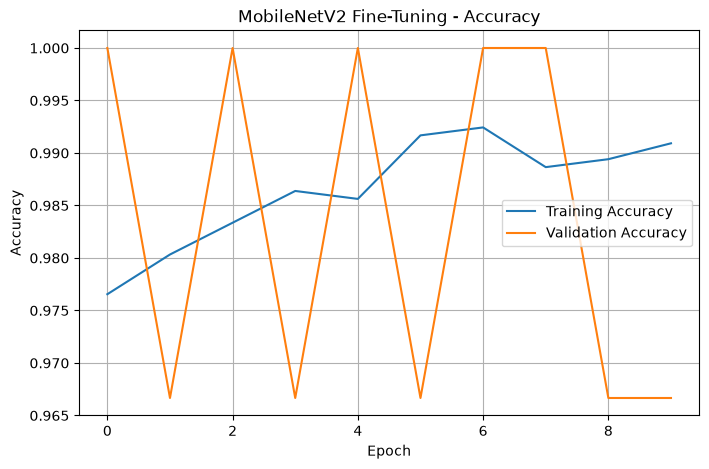

In [68]:
# 28. Plot Fine-Tuning Accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    fine_tune_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    fine_tune_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("MobileNetV2 Fine-Tuning - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

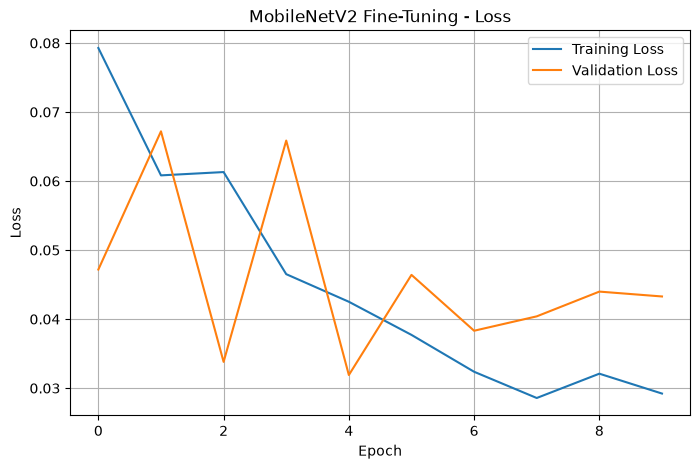

In [69]:
# Fine-Tuning Loss

plt.figure(figsize=(8, 5))

plt.plot(
    fine_tune_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    fine_tune_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("MobileNetV2 Fine-Tuning - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [70]:
# 29. Record MNV2-FT-01 Results

fine_tune_result = {
    "experiment_id": "MNV2-FT-01",
    "model": "MobileNetV2",
    "weights": "ImageNet",
    "input_size": "224x224",
    "batch_size": 32,
    "dropout": 0.2,
    "fine_tune_from_layer": 134,
    "trainable_backbone_layers": 13,
    "batch_normalization_frozen": True,
    "backbone_frozen": False,
    "initial_learning_rate": 1e-5,
    "epochs_max": 15,
    "epochs_run": len(fine_tune_history.history["loss"]),
    "best_epoch": int(np.argmin(fine_tune_history.history["val_loss"])) + 1,
    "best_val_loss": float(min(fine_tune_history.history["val_loss"])),
    "best_val_accuracy": float(max(fine_tune_history.history["val_accuracy"])),
    "training_time_seconds": fine_tune_time,
}

for key, value in fine_tune_result.items():
    print(f"{key}: {value}")

experiment_id: MNV2-FT-01
model: MobileNetV2
weights: ImageNet
input_size: 224x224
batch_size: 32
dropout: 0.2
fine_tune_from_layer: 134
trainable_backbone_layers: 13
batch_normalization_frozen: True
backbone_frozen: False
initial_learning_rate: 1e-05
epochs_max: 15
epochs_run: 10
best_epoch: 5
best_val_loss: 0.03190036490559578
best_val_accuracy: 1.0
training_time_seconds: 181.49635314941406


In [71]:
# 30. Generate Final Test Predictions

import numpy as np

test_probabilities = mobilenet_model.predict(
    test_pipeline,
    verbose=1
)

test_predictions = np.argmax(
    test_probabilities,
    axis=1
)

# Collect true labels
test_true_labels = np.concatenate([
    labels.numpy()
    for _, labels in test_pipeline
])

print("Prediction shape:", test_probabilities.shape)
print("Predicted labels shape:", test_predictions.shape)
print("True labels shape:", test_true_labels.shape)

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 209ms/step
Prediction shape: (150, 3)
Predicted labels shape: (150,)
True labels shape: (150,)


In [73]:
# 31. Final Classification Metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

test_accuracy = accuracy_score(
    test_true_labels,
    test_predictions
)

test_precision = precision_score(
    test_true_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)

test_recall = recall_score(
    test_true_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)

test_f1 = f1_score(
    test_true_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)

print("Final MobileNetV2 Test Results")
print("--------------------------------")
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        test_true_labels,
        test_predictions,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)

Final MobileNetV2 Test Results
--------------------------------
Accuracy : 0.9467
Precision: 0.9482
Recall   : 0.9467
F1-score : 0.9470

Classification Report:
              precision    recall  f1-score   support

     Healthy     0.9231    0.9600    0.9412        50
     Powdery     0.9216    0.9400    0.9307        50
        Rust     1.0000    0.9400    0.9691        50

    accuracy                         0.9467       150
   macro avg     0.9482    0.9467    0.9470       150
weighted avg     0.9482    0.9467    0.9470       150



Confusion Matrix:
[[48  2  0]
 [ 3 47  0]
 [ 1  2 47]]


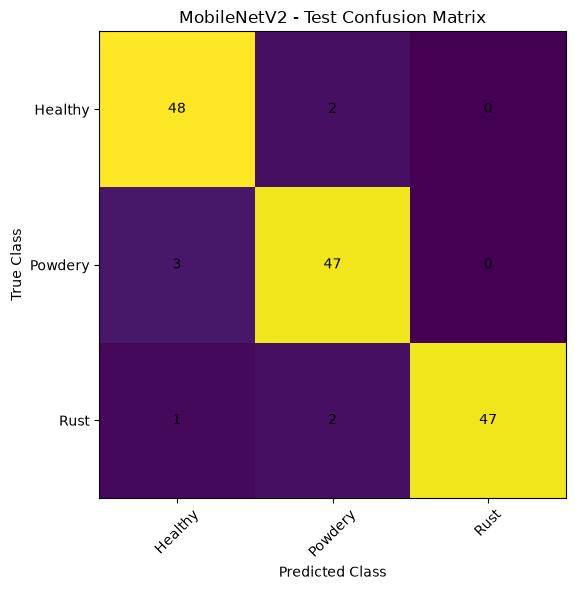

In [74]:
# 32. Confusion Matrix

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(
    test_true_labels,
    test_predictions
)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.title("MobileNetV2 - Test Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.xticks(
    range(NUM_CLASSES),
    CLASS_NAMES,
    rotation=45
)

plt.yticks(
    range(NUM_CLASSES),
    CLASS_NAMES
)

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [75]:
# 33. Multiclass ROC-AUC

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

test_true_one_hot = label_binarize(
    test_true_labels,
    classes=range(NUM_CLASSES)
)

test_roc_auc = roc_auc_score(
    test_true_one_hot,
    test_probabilities,
    multi_class="ovr",
    average="weighted"
)

print(f"Weighted Multiclass ROC-AUC: {test_roc_auc:.4f}")

Weighted Multiclass ROC-AUC: 0.9976


In [76]:
# 34. Final MobileNetV2 Evaluation Record

final_mobilenet_result = {
    "experiment_id": "MNV2-FT-01",
    "model": "MobileNetV2",
    "evaluation_set": "Test",
    "test_samples": len(test_true_labels),
    "accuracy": float(test_accuracy),
    "weighted_precision": float(test_precision),
    "weighted_recall": float(test_recall),
    "weighted_f1": float(test_f1),
    "weighted_roc_auc": float(test_roc_auc),
}

for key, value in final_mobilenet_result.items():
    print(f"{key}: {value}")

experiment_id: MNV2-FT-01
model: MobileNetV2
evaluation_set: Test
test_samples: 150
accuracy: 0.9466666666666667
weighted_precision: 0.9482151835093011
weighted_recall: 0.9466666666666667
weighted_f1: 0.9469805682812065
weighted_roc_auc: 0.9975999999999999


In [77]:
# 35. Identify Misclassified Test Images

misclassified_indices = np.where(
    test_true_labels != test_predictions
)[0]

print("Number of misclassified images:", len(misclassified_indices))
print()

for idx in misclassified_indices:
    true_class = CLASS_NAMES[test_true_labels[idx]]
    predicted_class = CLASS_NAMES[test_predictions[idx]]
    confidence = float(np.max(test_probabilities[idx]))

    print(
        f"Index: {idx:3d} | "
        f"True: {true_class:8s} | "
        f"Predicted: {predicted_class:8s} | "
        f"Confidence: {confidence:.4f}"
    )

Number of misclassified images: 8

Index:  16 | True: Healthy  | Predicted: Powdery  | Confidence: 0.9863
Index:  23 | True: Healthy  | Predicted: Powdery  | Confidence: 0.7030
Index:  55 | True: Powdery  | Predicted: Healthy  | Confidence: 0.7940
Index:  61 | True: Powdery  | Predicted: Healthy  | Confidence: 0.5257
Index:  99 | True: Powdery  | Predicted: Healthy  | Confidence: 0.8396
Index: 113 | True: Rust     | Predicted: Healthy  | Confidence: 0.5229
Index: 128 | True: Rust     | Predicted: Powdery  | Confidence: 0.8841
Index: 137 | True: Rust     | Predicted: Powdery  | Confidence: 0.6477


In [78]:
# 36. Map Misclassified Indices to Filenames

test_file_paths = []

for class_name in CLASS_NAMES:
    class_dir = TEST_DIR / class_name

    class_files = sorted([
        p for p in class_dir.iterdir()
        if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ])

    test_file_paths.extend(class_files)

print("Total test files:", len(test_file_paths))
print()

for idx in misclassified_indices:
    file_path = test_file_paths[idx]

    true_class = CLASS_NAMES[test_true_labels[idx]]
    predicted_class = CLASS_NAMES[test_predictions[idx]]
    confidence = float(np.max(test_probabilities[idx]))

    print(
        f"Index: {idx:3d} | "
        f"True: {true_class:8s} | "
        f"Predicted: {predicted_class:8s} | "
        f"Confidence: {confidence:.4f}"
    )
    print(f"File: {file_path.name}")
    print()

Total test files: 150

Index:  16 | True: Healthy  | Predicted: Powdery  | Confidence: 0.9863
File: 8e858c8397706b7b.jpg

Index:  23 | True: Healthy  | Predicted: Powdery  | Confidence: 0.7030
File: 8eb3b68893378387.jpg

Index:  55 | True: Powdery  | Predicted: Healthy  | Confidence: 0.7940
File: 81e5fcf446a9270b.jpg

Index:  61 | True: Powdery  | Predicted: Healthy  | Confidence: 0.5257
File: 82c3830f3bd2d1db.jpg

Index:  99 | True: Powdery  | Predicted: Healthy  | Confidence: 0.8396
File: 9ff7d2a548203c4b.jpg

Index: 113 | True: Rust     | Predicted: Healthy  | Confidence: 0.5229
File: 85e36e1b30afca61.jpg

Index: 128 | True: Rust     | Predicted: Powdery  | Confidence: 0.8841
File: 89e926943ba5693b.jpg

Index: 137 | True: Rust     | Predicted: Powdery  | Confidence: 0.6477
File: 93b2a2dec65c2b43.jpg



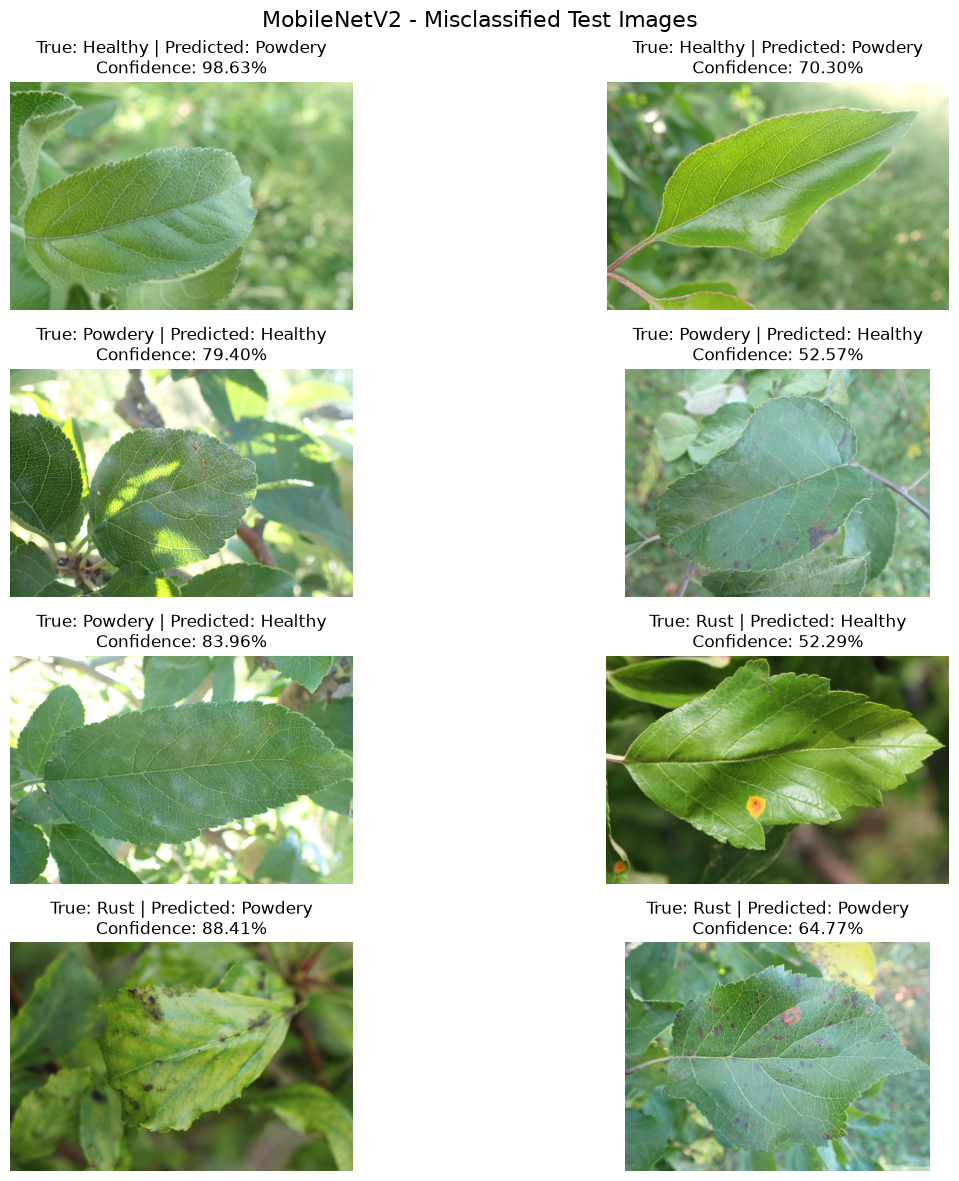

In [79]:
# 37. Visualize Misclassified Test Images

from PIL import Image

plt.figure(figsize=(14, 12))

for plot_position, idx in enumerate(misclassified_indices):
    file_path = test_file_paths[idx]

    image = Image.open(file_path).convert("RGB")

    true_class = CLASS_NAMES[test_true_labels[idx]]
    predicted_class = CLASS_NAMES[test_predictions[idx]]
    confidence = float(np.max(test_probabilities[idx]))

    ax = plt.subplot(4, 2, plot_position + 1)

    ax.imshow(image)

    ax.set_title(
        f"True: {true_class} | "
        f"Predicted: {predicted_class}\n"
        f"Confidence: {confidence:.2%}"
    )

    ax.axis("off")

plt.suptitle(
    "MobileNetV2 - Misclassified Test Images",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [80]:
# 39. Detailed Misclassification Analysis

error_analysis = []

for idx in misclassified_indices:
    probabilities = test_probabilities[idx]

    error_analysis.append({
        "index": int(idx),
        "filename": test_file_paths[idx].name,
        "true_class": CLASS_NAMES[test_true_labels[idx]],
        "predicted_class": CLASS_NAMES[test_predictions[idx]],
        "confidence": float(np.max(probabilities)),
        "healthy_probability": float(probabilities[0]),
        "powdery_probability": float(probabilities[1]),
        "rust_probability": float(probabilities[2])
    })

import pandas as pd

error_df = pd.DataFrame(error_analysis)

error_df


,index,filename,true_class,predicted_class,confidence,healthy_probability,powdery_probability,rust_probability
0,16,8e858c8397706b7b.jpg,Healthy,Powdery,0.986279,0.013719,0.986279,0.000002
1,23,8eb3b68893378387.jpg,Healthy,Powdery,0.702972,0.296928,0.702972,0.000100
2,55,81e5fcf446a9270b.jpg,Powdery,Healthy,0.793997,0.793997,0.112431,0.093572
3,61,82c3830f3bd2d1db.jpg,Powdery,Healthy,0.525745,0.525745,0.362790,0.111465
4,99,9ff7d2a548203c4b.jpg,Powdery,Healthy,0.839626,0.839626,0.150167,0.010207
5,113,85e36e1b30afca61.jpg,Rust,Healthy,0.522854,0.522854,0.054508,0.422638
6,128,89e926943ba5693b.jpg,Rust,Powdery,0.884055,0.059741,0.884055,0.056204
7,137,93b2a2dec65c2b43.jpg,Rust,Powdery,0.647652,0.170938,0.647652,0.181410


In [81]:
# Save MobileNetV2 error analysis

error_df.to_csv(
    "../results/mobilenetv2_error_analysis.csv",
    index=False
)

print("Error analysis saved successfully.")

Error analysis saved successfully.


In [82]:
# 40. Error Counts by Confusion Pair

error_pairs = (
    error_df
    .groupby(["true_class", "predicted_class"])
    .size()
    .reset_index(name="error_count")
)

error_pairs

,true_class,predicted_class,error_count
0,Healthy,Powdery,2
1,Powdery,Healthy,3
2,Rust,Healthy,1
3,Rust,Powdery,2


In [83]:
# 42. Save MobileNetV2 Final Results

mobilenet_final_results = pd.DataFrame([{
    "experiment_id": "MNV2-FT-01",
    "model": "MobileNetV2",
    "test_samples": 150,
    "accuracy": test_accuracy,
    "weighted_precision": test_precision,
    "weighted_recall": test_recall,
    "weighted_f1": test_f1,
    "weighted_roc_auc": test_roc_auc,
    "best_val_accuracy": fine_tune_result["best_val_accuracy"],
    "best_val_loss": fine_tune_result["best_val_loss"],
    "best_epoch": fine_tune_result["best_epoch"],
    "training_time_seconds": fine_tune_time,
    "training_time_minutes": fine_tune_time / 60,
    "fine_tune_from_layer": 134,
    "trainable_backbone_layers": 13,
    "initial_learning_rate": 1e-5,
    "batch_size": 32,
    "input_size": "224x224",
    "dropout": 0.2
}])

mobilenet_final_results.to_csv(
    "../results/mobilenetv2_final_results.csv",
    index=False
)

print("MobileNetV2 final results saved successfully.")
display(mobilenet_final_results)

MobileNetV2 final results saved successfully.


,experiment_id,model,test_samples,accuracy,weighted_precision,weighted_recall,weighted_f1,weighted_roc_auc,best_val_accuracy,best_val_loss,best_epoch,training_time_seconds,training_time_minutes,fine_tune_from_layer,trainable_backbone_layers,initial_learning_rate,batch_size,input_size,dropout
0,MNV2-FT-01,MobileNetV2,150,0.946667,0.948215,0.946667,0.946981,0.9976,1.0,0.0319,5,181.496353,3.024939,134,13,0.00001,32,224x224,0.2


In [84]:
# 43. MobileNetV2 Experiment Comparison

mobilenet_comparison = pd.DataFrame([
    {
        "Experiment": "MNV2-BASE-01",
        "Backbone": "Frozen",
        "Trainable Layers": 0,
        "Learning Rate": 0.001,
        "Best Val Accuracy": 0.9833,
        "Best Val Loss": 0.0784,
        "Best Epoch": 9,
        "Training Time (min)": 4.77
    },
    {
        "Experiment": "MNV2-FT-01",
        "Backbone": "13 upper layers fine-tuned",
        "Trainable Layers": 13,
        "Learning Rate": 0.00001,
        "Best Val Accuracy": 1.0000,
        "Best Val Loss": 0.0319,
        "Best Epoch": 5,
        "Training Time (min)": 3.02
    }
])

display(mobilenet_comparison)

,Experiment,Backbone,Trainable Layers,Learning Rate,Best Val Accuracy,Best Val Loss,Best Epoch,Training Time (min)
0,MNV2-BASE-01,Frozen,0,0.00100,0.9833,0.0784,9,4.77
1,MNV2-FT-01,13 upper layers fine-tuned,13,0.00001,1.0000,0.0319,5,3.02


In [85]:
# 44. Save MobileNetV2 Experiment Comparison

mobilenet_comparison.to_csv(
    "../results/mobilenetv2_experiment_comparison.csv",
    index=False
)

print("MobileNetV2 experiment comparison saved successfully.")

MobileNetV2 experiment comparison saved successfully.


In [86]:
# 45. Save Preprocessing Configuration

preprocessing_config = {
    "image_size": "224x224",
    "batch_size": 32,
    "class_names": CLASS_NAMES,
    "num_classes": NUM_CLASSES,
    "seed": SEED,

    "augmentation": {
        "enabled_for_training": True,
        "enabled_for_validation": False,
        "enabled_for_test": False,
        "horizontal_flip": True,
        "rotation_factor": 0.05,
        "translation_factor": 0.05,
        "zoom_factor": 0.10
    },

    "model_specific_preprocessing": {
        "model": "MobileNetV2",
        "function": "tf.keras.applications.mobilenet_v2.preprocess_input",
        "output_range": "-1 to 1"
    },

    "dataset_split_usage": {
        "training": "train_pipeline",
        "validation": "validation_pipeline",
        "test": "test_pipeline"
    }
}

import json

with open(
    "../results/mobilenetv2_preprocessing_config.json",
    "w"
) as f:
    json.dump(preprocessing_config, f, indent=4)

print("Preprocessing configuration saved successfully.")

Preprocessing configuration saved successfully.


In [87]:
# 46. Save Confusion Matrix

cm_df = pd.DataFrame(
    cm,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
)

cm_df.to_csv(
    "../results/mobilenetv2_confusion_matrix.csv"
)

print("Confusion matrix saved successfully.")
display(cm_df)

Confusion matrix saved successfully.


,Healthy,Powdery,Rust
Healthy,48,2,0
Powdery,3,47,0
Rust,1,2,47


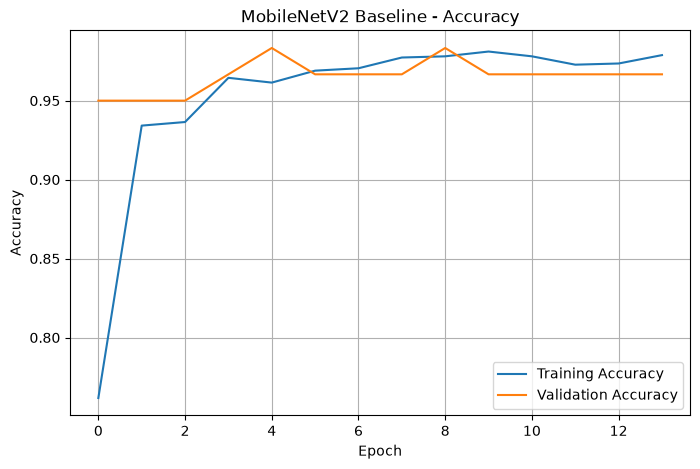

In [88]:
# 47A. Save Baseline Accuracy Curve

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("MobileNetV2 Baseline - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.savefig(
    "../results/mobilenetv2_baseline_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

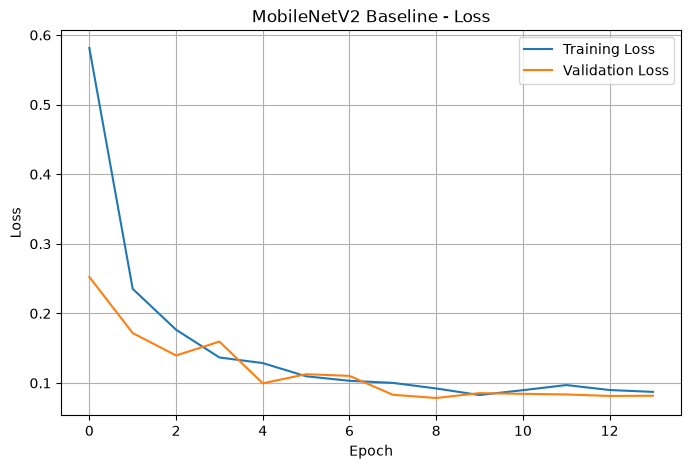

In [89]:
# 47B. Save Baseline Loss Curve

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("MobileNetV2 Baseline - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.savefig(
    "../results/mobilenetv2_baseline_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

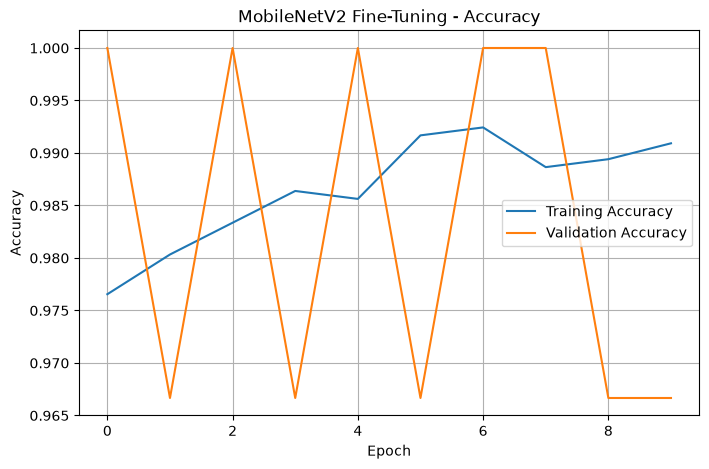

In [90]:
# 47C. Save Fine-Tuning Accuracy Curve

plt.figure(figsize=(8, 5))

plt.plot(
    fine_tune_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    fine_tune_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("MobileNetV2 Fine-Tuning - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.savefig(
    "../results/mobilenetv2_finetuning_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

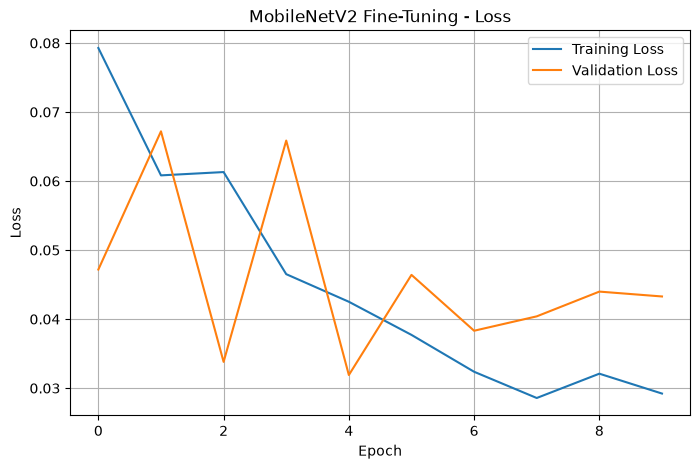

In [91]:
# 47D. Save Fine-Tuning Loss Curve

plt.figure(figsize=(8, 5))

plt.plot(
    fine_tune_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    fine_tune_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("MobileNetV2 Fine-Tuning - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.savefig(
    "../results/mobilenetv2_finetuning_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [92]:
# 48. Save Final MobileNetV2 Model

MODEL_PATH = "../models/mobilenetv2_ft.keras"

mobilenet_model.save(MODEL_PATH)

print("Final MobileNetV2 model saved.")
print(MODEL_PATH)

Final MobileNetV2 model saved.
../models/mobilenetv2_ft.keras
